In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print("사용할 PyTorch 버전:", torch.__version__, ' Device:', DEVICE)

# 한번 학습시 몇 개의 사진을 이용하는지
BATCH_SIZE = 32
# 학습을 몇 번 할 건지
EPOCHS = 10
# 학습할 때 가중치를 얼마나 조금씩 바꿀지
LEARNING_RATE = 0.001


사용할 PyTorch 버전: 2.13.0+cu130  Device: cpu


/home/kim/Desktop/YoungJae/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
train_dataset = datasets.MNIST(root = "./data/MNIST",
                               train = True,
                               download = True,
                               transform = transforms.ToTensor())

test_dataset = datasets.MNIST(root = "./data/MNIST",
                              train = False,
                              transform = transforms.ToTensor())

# BATCH_SIZE 크기만큼 분리
train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                           batch_size = BATCH_SIZE,
                                           shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = BATCH_SIZE,
                                          shuffle = False)

In [4]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor


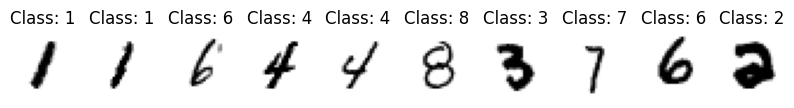

In [5]:
pltsize = 1
plt.figure(figsize=(10 * pltsize, pltsize)) #10개 plot하기 위한 figure 크기 설정

for i in range(10):
    plt.subplot(1, 10, i + 1) # plot.subplot(rows, columns, index)
    plt.axis('off')
    plt.imshow(X_train[i, :, :, :].numpy().reshape(28, 28), cmap = "gray_r")
    plt.title('Class: ' + str(y_train[i].item()))

In [6]:
class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # 첫 번째 CNN layer입니다.
        # 1장의 흑백 이미지에서 32개의 특징 지도를 만듭니다.
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 두 번째 CNN layer입니다.
        # 앞에서 찾은 32개의 단서를 다시 조합해서 64개의 더 깊은 단서를 만듭니다.
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 마지막에는 CNN이 찾은 단서를 한 줄로 펼친 뒤 0~9 중 하나를 고릅니다.
        self.fc = torch.nn.Linear(7 * 7 * 64, 10, bias=True)
        torch.nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


In [11]:
model = CNN().to(DEVICE)
print(model)


CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)


In [12]:
criterion = torch.nn.CrossEntropyLoss().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [13]:
total_batch = len(train_loader)
print('Learning started. It takes sometime.')

for epoch in range(EPOCHS):
    model.train()
    avg_cost = 0

    for X, Y in train_loader:
        X = X.to(DEVICE)
        Y = Y.to(DEVICE)

        optimizer.zero_grad()
        hypothesis = model(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost.item()))

print('Learning Finished!')


Learning started. It takes sometime.
[Epoch:    1] cost = 0.154916674
[Epoch:    2] cost = 0.0496640317
[Epoch:    3] cost = 0.0355384126
[Epoch:    4] cost = 0.0269370191
[Epoch:    5] cost = 0.0218234789
[Epoch:    6] cost = 0.0165849142
[Epoch:    7] cost = 0.0140627874
[Epoch:    8] cost = 0.0106447656
[Epoch:    9] cost = 0.00875673257
[Epoch:   10] cost = 0.00770101836
Learning Finished!


In [14]:
model.eval()
correct = 0

with torch.no_grad():
    for X_test, Y_test in test_loader:
        X_test = X_test.to(DEVICE)
        Y_test = Y_test.to(DEVICE)

        prediction = model(X_test)
        correct_prediction = torch.argmax(prediction, dim=1) == Y_test
        correct += correct_prediction.sum().item()

accuracy = correct / len(test_dataset)
print('Accuracy:', accuracy)


Accuracy: 0.9908


## 마지막 이미지 검증

전체 정확도는 평균 점수입니다. 그런데 실제 이미지를 직접 보면 모델이 어떤 숫자를 맞히고 틀리는지 더 쉽게 알 수 있습니다.

아래 코드는 테스트 이미지 20장을 보여주고, 그림 위에 모델의 예측값과 실제 정답을 같이 표시합니다.
초록색 제목은 맞힌 것, 빨간색 제목은 틀린 것입니다.


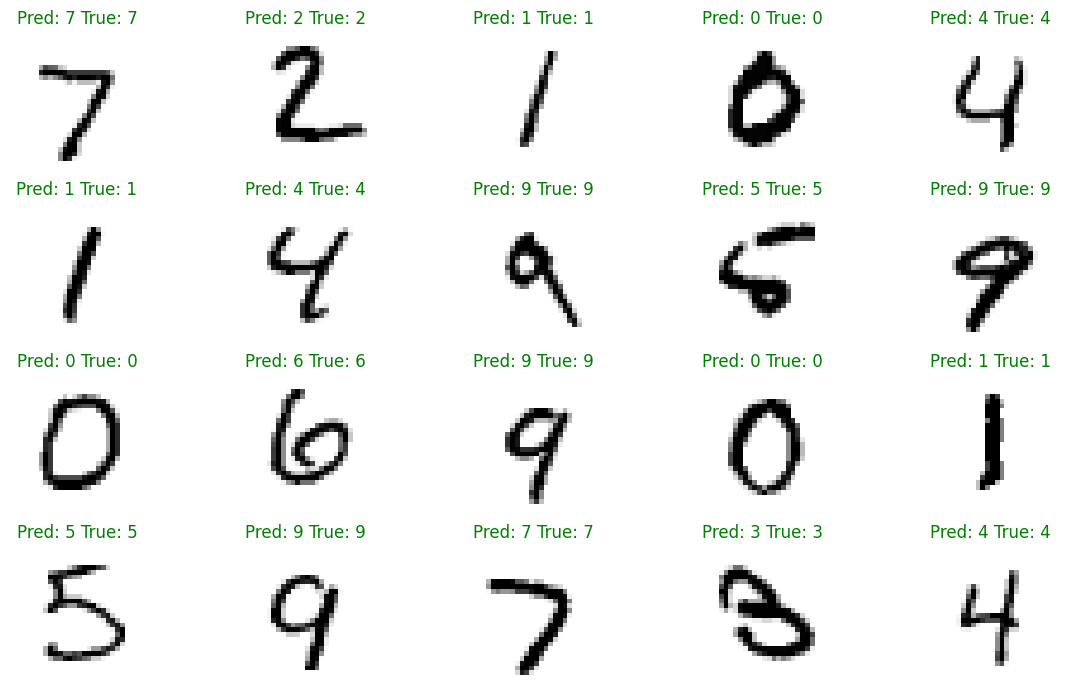

In [19]:
# 테스트 이미지 몇 장을 눈으로 확인합니다.
sample_images, sample_labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    sample_outputs = model(sample_images.to(DEVICE))
    sample_predictions = sample_outputs.argmax(dim=1).cpu()

plt.figure(figsize=(12, 7))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.axis('off')
    plt.imshow(sample_images[i].squeeze().numpy(), cmap='gray_r')

    true_label = sample_labels[i].item()
    predicted_label = sample_predictions[i].item()
    title_color = 'green' if true_label == predicted_label else 'red'
    plt.title(f'Pred: {predicted_label} \
True: {true_label}', color=title_color)

plt.tight_layout()
plt.show()


## CNN layer가 보는 특징 시각화

CNN은 이미지를 한 번에 외우는 것이 아니라, 작은 필터로 여러 단서를 찾습니다.

쉽게 말하면 이런 순서입니다.

| 단계 | 쉬운 설명 |
|---|---|
| 원본 이미지 | 사람이 보는 숫자 그림 |
| Layer 1 | 짧은 선, 끝부분, 꺾인 부분 같은 간단한 단서를 찾음 |
| Layer 2 | 앞에서 찾은 단서를 합쳐서 둥근 모양, 긴 획 같은 더 큰 단서를 찾음 |

아래 그림에서 밝게 보이는 부분은 그 layer가 강하게 반응한 부분입니다. 즉, 모델이 “여기가 중요해 보인다”고 느낀 곳이라고 생각하면 됩니다.


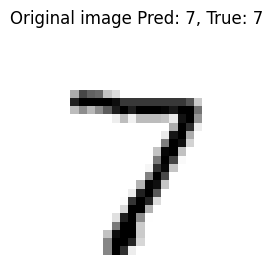

/tmp/ipykernel_2944819/1621309444.py:35: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2944819/1621309444.py:35: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2944819/1621309444.py:35: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2944819/1621309444.py:35: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2944819/1621309444.py:35: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2944819/1621309444.py:35: UserWarning: Glyph 51025 (\N{HANGUL SYLLABLE EUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2944819/1621309444.py:35: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu 

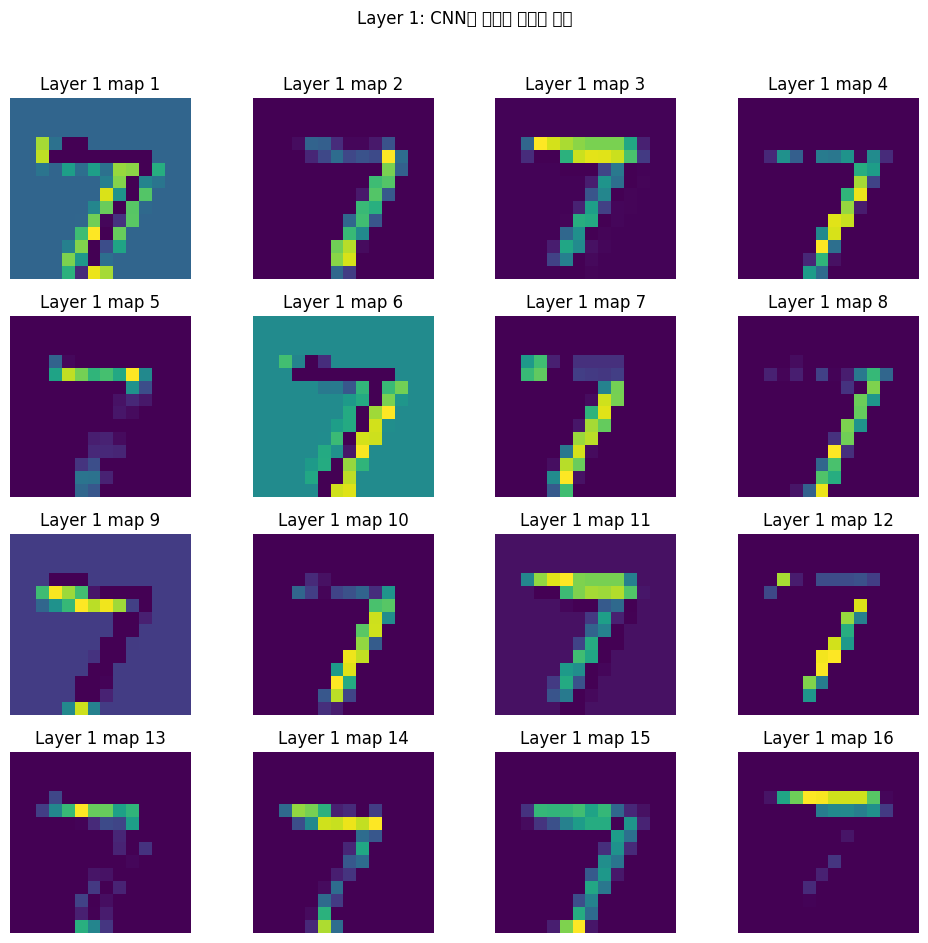

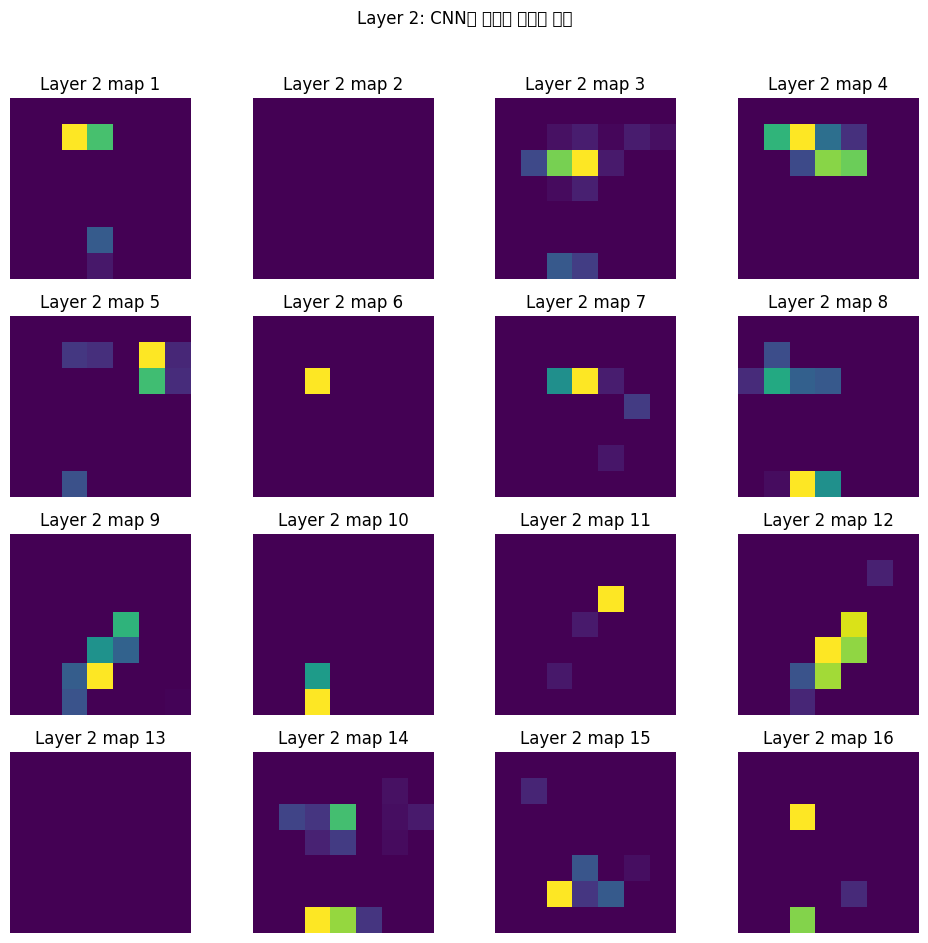

In [20]:
# 한 장의 테스트 이미지를 골라 CNN layer가 어떻게 반응하는지 봅니다.
sample_index = 0
image, label = test_dataset[sample_index]
input_image = image.unsqueeze(0).to(DEVICE)

model.eval()
with torch.no_grad():
    layer1_features = model.layer1(input_image)
    layer2_features = model.layer2(layer1_features)
    output = model(input_image)
    predicted_label = output.argmax(dim=1).item()

plt.figure(figsize=(3, 3))
plt.axis('off')
plt.imshow(image.squeeze().numpy(), cmap='gray_r')
plt.title(f'Original image \
Pred: {predicted_label}, True: {label}')
plt.show()


def show_feature_maps(feature_maps, layer_name, max_maps=16):
    feature_maps = feature_maps.squeeze(0).detach().cpu()
    map_count = min(max_maps, feature_maps.size(0))
    cols = 4
    rows = int(np.ceil(map_count / cols))

    plt.figure(figsize=(10, rows * 2.3))
    for i in range(map_count):
        plt.subplot(rows, cols, i + 1)
        plt.axis('off')
        plt.imshow(feature_maps[i], cmap='viridis')
        plt.title(f'{layer_name} map {i + 1}')

    plt.suptitle(f'{layer_name}: CNN이 강하게 반응한 부분', y=1.02)
    plt.tight_layout()
    plt.show()


show_feature_maps(layer1_features, 'Layer 1')
show_feature_maps(layer2_features, 'Layer 2')


## 첫 번째 CNN 필터 확인

아래는 첫 번째 convolution layer의 필터 일부입니다.
필터는 아주 작은 3 x 3 돋보기처럼 움직이면서 이미지의 단서를 찾습니다.

처음에는 랜덤에 가깝지만, 학습이 끝난 뒤에는 선이나 방향 같은 단서에 반응하도록 값이 바뀝니다.


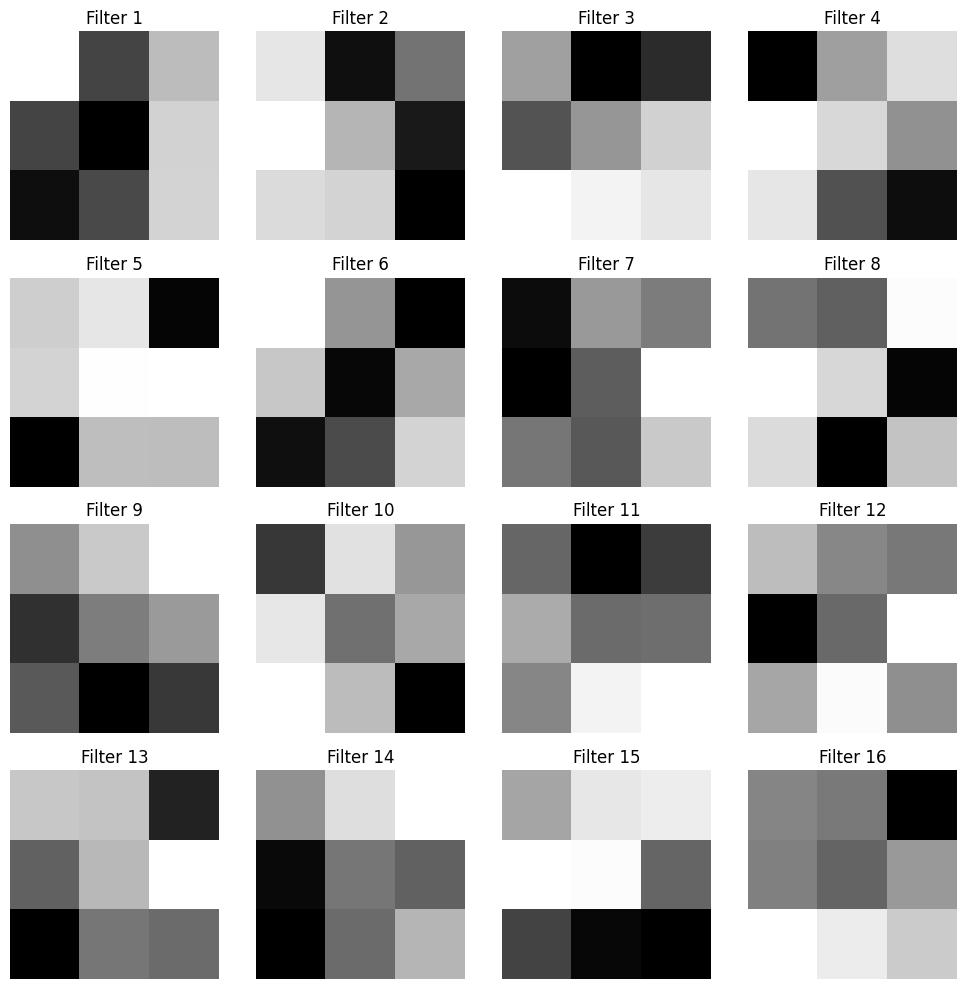

In [26]:
# 첫 번째 convolution layer가 학습한 필터를 봅니다.
conv1_filters = model.layer1[0].weight.detach().cpu()
filter_count = min(16, conv1_filters.size(0))

plt.figure(figsize=(10, 10))
for i in range(filter_count):
    plt.subplot(4, 4, i + 1)
    plt.axis('off')
    plt.imshow(conv1_filters[i, 0], cmap='gray')
    plt.title(f'Filter {i + 1}')

# plt.suptitle('Layer 1 learned filters', y=0.93)
plt.tight_layout()
plt.show()
